# meent torch backend 시뮬레이션 예제 — raster / vector 모델링 + 물질 테이블

같은 2D 격자 구조를 **두 가지 모델링 방식**으로 각각 세우고 푸는 예제입니다. 굴절률은 직접
적어 넣지 않고 `meent/nk_data/`의 **물질 테이블에서 불러옵니다**.

| 방식 | ucell 타입 | 구조 표현 | 언제 쓰나 |
| --- | --- | --- | --- |
| **raster** | `ndarray` / `Tensor`, `(layer, y, x)` | 픽셀 격자 | 자유형상(freeform), 위상최적화, 이미지로 주어진 패턴 |
| **vector** | `list` (레이어별 도형 명령) | 도형(사각형·타원)의 경계 좌표 | 파라미터가 몇 개뿐인 구조, 픽셀 계단현상 없이 정확한 경계가 필요할 때 |

`meent`가 둘을 구분하는 기준은 `mee.ucell`에 넣은 **자료형 하나**입니다. 배열이면 raster,
리스트면 vector로 잡히고(`meent/on_torch/emsolver/rcwa.py`의 `ucell` setter), 그 뒤 호출은
`mee.conv_solve()`로 동일합니다.

> **단위: 이 노트북은 길이를 전부 m로 씁니다.** 파장, 주기, 두께, 도형 치수, 물질 표 조회까지
> 모두 m입니다. meent 솔버 자체는 단위에 무관하지만(파장과 길이의 비만 관계) 물질 표는 m로
> 고정돼 있으므로, 전부 m로 맞추면 변환할 곳이 없습니다.

다루는 내용

1. 물질 테이블에서 굴절률 불러오기
2. 공통 구조 정의
3. **raster type** 시뮬레이션
4. **vector type** 시뮬레이션
5. 두 방식 비교 — raster 픽셀 해상도 수렴성
6. 파장 스윕 (분산 반영)
7. 전기장 분포
8. torch autograd — 구조 파라미터에 대한 미분과 최적화

## 0. 준비

`pip install meent`로 설치했고 그 버전을 쓰려면 아래 셀은 건너뛰어도 됩니다. 설치하지 않은
저장소(checkout)를 그대로 쓰거나, 설치본보다 checkout을 우선시키려면 실행하세요.

아래 셀은 현재 폴더에서 위로 올라가며 `meent/__init__.py`가 있는 곳을 저장소 루트로 잡습니다.
커널 작업 폴더가 어디든 동작하고, 이미 다른 `meent`가 import 돼 있으면 캐시에서 비워
다시 잡히게 합니다.

In [1]:
import os
import sys
from pathlib import Path

# 저장소 루트. None이면 현재 폴더에서 위로 올라가며 자동으로 찾습니다.
# 자동 탐색이 실패하거나 다른 checkout을 쓰고 싶으면 여기에 직접 적으세요.
MEENT_ROOT = None  # 예: MEENT_ROOT = r'E:\Taesang Yun\meent'

if MEENT_ROOT is None:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'meent' / '__init__.py').is_file():
            MEENT_ROOT = str(candidate)
            break

if MEENT_ROOT is None:
    raise RuntimeError(f'meent checkout을 찾지 못했습니다 (현재 폴더: {Path.cwd()}). '
                       'MEENT_ROOT를 직접 지정하세요.')

# 이미 import 된 meent가 있으면 sys.path를 고쳐도 그게 계속 쓰입니다. 캐시에서 비웁니다.
for name in [name for name in sys.modules if name == 'meent' or name.startswith('meent.')]:
    del sys.modules[name]

# pip로 설치된 meent보다 이 checkout이 우선하도록 맨 앞에 넣습니다.
sys.path.insert(0, MEENT_ROOT)

print('cwd        :', Path.cwd())
print('MEENT_ROOT :', MEENT_ROOT)

cwd        : e:\Taesang Yun\meent\examples
MEENT_ROOT : e:\Taesang Yun\meent


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

import meent

BACKEND = 2  # 0=numpy, 1=jax, 2=torch

print('meent   :', os.path.dirname(meent.__file__ or '(namespace package)'))
print('version :', meent.__version__)
print('torch   :', torch.__version__)

# 의도한 곳에서 import 됐는지 확인. 여기서 걸리면 위 셀의 MEENT_ROOT가 틀렸거나,
# 물질 조회 함수가 없는 옛 버전이 잡힌 것입니다 (커널 재시작 후 다시 실행해 보세요).
missing = [name for name in ('call_mee', 'read_material_table', 'find_nk_index', 'list_materials')
           if not hasattr(meent, name)]
if missing:
    raise RuntimeError(
        f'import 된 meent에 {missing} 이(가) 없습니다.\n'
        f'  import 위치: {meent.__file__}\n'
        f'  기대한 위치: {os.path.join(MEENT_ROOT, "meent", "__init__.py")}\n'
        '커널을 재시작하고 첫 셀부터 다시 실행하세요.')

meent   : e:\Taesang Yun\meent\meent
version : 0.13.2
torch   : 2.13.0+cpu


## 1. 물질 값 불러오기

`meent.read_material_table()`이 `meent/nk_data/` 아래 모든 표를 읽어 한 딕셔너리로 돌려주고,
`meent.find_nk_index(name, table, wl)`이 그 표에서 파장 `wl`의 복소 굴절률을 뽑습니다.

**표의 파장 단위가 m이고, 이 노트북은 모든 길이를 m로 쓰므로 변환할 것이 없습니다.**

한 물질에 여러 데이터셋이 있으므로(`<물질>_<출처>`) **파장 범위를 반드시 확인**하세요. 범위를
벗어나면 예외가 아니라 끝값으로 clamp 되면서 경고만 나옵니다.

In [3]:
table = meent.read_material_table()
print(f'테이블에 있는 물질 수: {len(table)}')

# 이번 예제에서 쓸 후보들만 추려서 파장 범위를 확인합니다.
# 전체 목록은 meent.print_materials() 로 볼 수 있습니다.
for material in meent.list_materials():
    if material['name'] in ('SI_GREEN-2008', 'SI_ASPNES', 'SIO2_MALITSON', 'SI3N4_LUKE', 'AU_JOHNSON'):
        print(f"{material['name']:16} {material['wl_min']:.3e} - {material['wl_max']:.3e} m   "
              f"{material['source'][:55]}")

테이블에 있는 물질 수: 49
AU_JOHNSON       1.879e-07 - 1.937e-06 m   P. B. Johnson and R. W. Christy. Optical constants of t
SI3N4_LUKE       3.100e-07 - 5.504e-06 m   K. Luke, Y. Okawachi, M. R. E. Lamont, A. L. Gaeta, M. 
SIO2_MALITSON    2.100e-07 - 6.700e-06 m   1) I. H. Malitson. Interspecimen comparison of the refr
SI_ASPNES        2.066e-07 - 8.266e-07 m   D. E. Aspnes and A. A. Studna. Dielectric functions and
SI_GREEN-2008    2.500e-07 - 1.450e-06 m   M. A. Green. Self-consistent optical parameters of intr


In [4]:
WAVELENGTH = 900e-9   # m

MAT_LIST = ['sio2_malitson', 'si_green-2008', 'si3n4_luke']  # raster에서 정수 0, 1, 2에 대응

# vector 모델링에는 이름이 아니라 굴절률 값을 직접 넣으므로 여기서 미리 뽑아 둡니다.
n_sio2 = complex(meent.find_nk_index('sio2_malitson', table, WAVELENGTH))
n_si = complex(meent.find_nk_index('si_green-2008', table, WAVELENGTH))
n_si3n4 = complex(meent.find_nk_index('si3n4_luke', table, WAVELENGTH))

print(f'@ {WAVELENGTH:.3e} m')
print(f'  SiO2  : {n_sio2}')
print(f'  Si    : {n_si}')
print(f'  Si3N4 : {n_si3n4}')

@ 9.000e-07 m
  SiO2  : (1.4517539550240655+0j)
  Si    : (3.614-0.0021701j)
  Si3N4 : (2.0183270622516525+0j)


흡수가 있는 물질은 허수부가 **음수**로 나옵니다. meent은 `n - ik` 규약으로 풀고 조회 함수가
그 부호까지 붙여 주므로, 받은 값을 **그대로** 쓰면 됩니다 — `.conj()`를 따로 씌우면 흡수체가
이득 매질이 되어 `R + T > 1`이 됩니다.

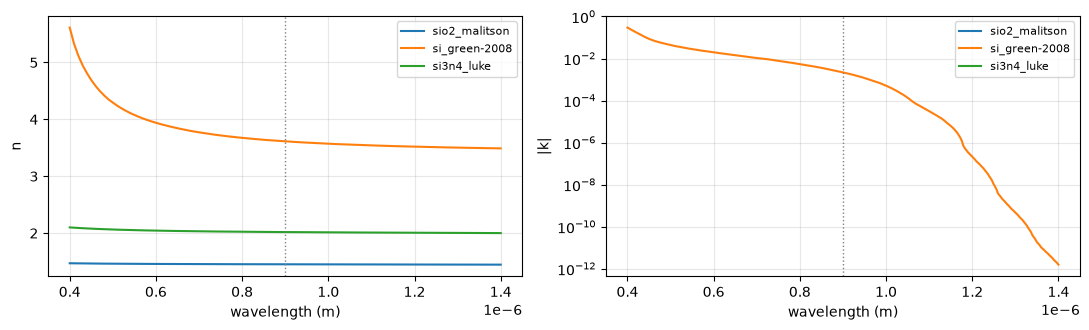

In [5]:
# 분산 곡선 — 파장을 바꾸면 굴절률도 바뀐다는 점이 6절 스윕의 전제입니다.
wavelength_grid = np.linspace(400e-9, 1400e-9, 300)

figure, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for name in MAT_LIST:
    nk = np.array([meent.find_nk_index(name, table, w) for w in wavelength_grid])
    axes[0].plot(wavelength_grid, nk.real, label=name)
    axes[1].plot(wavelength_grid, np.abs(nk.imag), label=name)

axes[0].set_ylabel('n')
axes[1].set_ylabel('|k|')
axes[1].set_yscale('log')
for axis in axes:
    axis.axvline(WAVELENGTH, color='gray', ls=':', lw=1)
    axis.set_xlabel('wavelength (m)')
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 공통 구조 정의

두 방식이 **같은 구조**를 표현하도록 치수를 한곳에 모아 둡니다. 전부 m입니다.

```
        ^ z
 n_top = 1 (공기)
 ┌───────────────────────────┐
 │ layer 1: SiO2 바탕 + Si 원기둥 │  220e-9 m
 ├───────────────────────────┤
 │ layer 2: Si3N4 바탕 + Si 라인  │  180e-9 m
 └───────────────────────────┘
 n_bot = Si3N4 (기판)
```

주기 1200e-9 m > 파장 900e-9 m 이므로 0차 외에 ±1차 회절도 전파합니다(3절의 차수별 효율 표에서
확인). `fto`는 유지할 푸리에 차수로, `[6, 6]`이면 x, y 각각 -6..+6 → 13 x 13 = 169개입니다.

In [ ]:
PERIOD = [1200e-9, 1200e-9]     # m, [x, y]
THICKNESS = [220e-9, 180e-9]    # m, 위층부터
FTO = [6, 6]

# layer 1: 원기둥 (SiO2 바탕 안의 Si)
PILLAR_CX, PILLAR_CY, PILLAR_D = 600e-9, 600e-9, 620e-9
# layer 2: 라인 격자 (Si3N4 바탕 안의 Si, y 방향으로 주기 전체를 관통)
LINE_CX, LINE_CY, LINE_W, LINE_H = 600e-9, 600e-9, 500e-9, 1200e-9

# 두 방식이 공유하는 솔버 설정.
# pol: 0=TE, 1=TM (0~1 사이 값이면 혼합), theta/phi: 입사각 (rad)
RCWA_OPTIONS = dict(
    backend=BACKEND,
    wavelength=WAVELENGTH,
    period=PERIOD,
    thickness=THICKNESS,
    fto=FTO,
    n_top=1.0,
    n_bot=n_si3n4.real,
    pol=0.0,
    theta=0.0,
    phi=0.0,
    device=0,             # 0=cpu, 1=gpu
    type_complex=0,       # 0=complex128, 1=complex64
)

## 3. raster type

`ucell`을 **정수 패턴**으로 그린 뒤 `put_refractive_index_in_ucell(pattern, mat_list, wl)`로
물질을 대입합니다. 정수 `i`가 `mat_list[i]`가 됩니다 — 여기서는 0=SiO2, 1=Si, 2=Si3N4.

`mat_list`에는 **물질 이름 문자열**과 굴절률 값을 섞어 쓸 수 있습니다. 문자열이면 내부에서
`find_nk_index`로 표를 조회하므로, 여기가 물질 값이 들어오는 지점입니다.

배열 모양은 `(레이어, y, x)`이고, `y` 방향 길이가 1이면 1D 격자로 취급됩니다.

In [ ]:
def make_pattern(n_pixel):
    # 공통 구조를 n_pixel x n_pixel 격자에 정수 패턴으로 래스터화
    x = (np.arange(n_pixel) + 0.5) * PERIOD[0] / n_pixel  # 픽셀 중심 좌표 (m)
    y = (np.arange(n_pixel) + 0.5) * PERIOD[1] / n_pixel
    xx, yy = np.meshgrid(x, y, indexing='xy')

    layer1 = np.zeros((n_pixel, n_pixel), dtype=int)      # 0 = SiO2 바탕
    layer1[(xx - PILLAR_CX) ** 2 + (yy - PILLAR_CY) ** 2 < (PILLAR_D / 2) ** 2] = 1   # 1 = Si

    layer2 = np.full((n_pixel, n_pixel), 2, dtype=int)    # 2 = Si3N4 바탕
    layer2[(np.abs(xx - LINE_CX) < LINE_W / 2) & (np.abs(yy - LINE_CY) < LINE_H / 2)] = 1

    return np.stack([layer1, layer2])                     # (레이어, y, x)


pattern = make_pattern(120)
print('pattern shape:', pattern.shape, '| 사용된 정수:', np.unique(pattern))

In [ ]:
mee_raster = meent.call_mee(**RCWA_OPTIONS)

# 정수 패턴 -> 복소 굴절률 텐서
mee_raster.ucell = mee_raster.put_refractive_index_in_ucell(pattern, MAT_LIST, WAVELENGTH)

print('ucell   :', type(mee_raster.ucell).__name__, tuple(mee_raster.ucell.shape), mee_raster.ucell.dtype)
print('굴절률  :', np.round(np.unique(mee_raster.ucell.numpy()), 4))
print('modeling_type_assigned:', mee_raster.modeling_type_assigned, '(0=raster, 1=vector)')

In [ ]:
# 그려진 패턴 확인. 그림 라벨은 영문 — matplotlib 기본 폰트에 한글 글리프가 없습니다.
figure, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for i, axis in enumerate(axes):
    image = axis.imshow(mee_raster.ucell[i].real.numpy(), origin='lower', cmap='viridis',
                        extent=[0, PERIOD[0], 0, PERIOD[1]])
    axis.set_title(f'layer {i + 1}  (t = {THICKNESS[i]:.2e} m)')
    axis.set_xlabel('x (m)')
    axis.set_ylabel('y (m)')
    plt.colorbar(image, ax=axis, label='n')
plt.tight_layout()
plt.show()

In [ ]:
result_raster = mee_raster.conv_solve()

de_ri = result_raster.de_ri   # 반사 차수별 효율, (2*fto_x+1, 2*fto_y+1)
de_ti = result_raster.de_ti   # 투과

R_raster = float(de_ri.sum())
T_raster = float(de_ti.sum())
print(f'R = {R_raster:.5f}')
print(f'T = {T_raster:.5f}')
print(f'R + T = {R_raster + T_raster:.5f}   (흡수 = {1 - R_raster - T_raster:.5f})')

`de_ri`/`de_ti`는 차수별 효율 행렬입니다. 중심이 0차이므로 인덱스 `[fto_x, fto_y]`가 0차이고,
전파하지 못하는(evanescent) 차수는 0으로 나옵니다.

In [ ]:
center = FTO[0]
window = slice(center - 2, center + 3)
orders = np.arange(-2, 3)

print('투과 효율 (행: x 차수, 열: y 차수)')
print('        ' + ''.join(f'{m:>10d}' for m in orders))
for row, m in zip(de_ti[window, window].numpy(), orders):
    print(f'{m:>6d}  ' + ''.join(f'{value:10.4f}' for value in row))
print(f'\n0차 투과 : {float(de_ti[center, center]):.5f}')
print(f'0차 반사 : {float(de_ri[center, center]):.5f}')

## 4. vector type

같은 구조를 **도형 명령 리스트**로 씁니다. 형식은

```python
ucell = [
    [바탕_굴절률, [ [도형이름, cx, cy, lx, ly, 굴절률, 회전각, n_split_x, n_split_y], ... ]],   # 레이어 1
    [바탕_굴절률, [ ... ]],                                                                   # 레이어 2
]
```

- 도형이름: `'rectangle'` 또는 `'ellipse'` (`ModelingTorch`의 메서드 이름을 그대로 부릅니다)
- 좌표와 치수는 m. 회전각은 rad. `n_split_*`는 회전/곡선 경계를 몇 조각의 직사각형으로 근사할지로,
  회전이 없는 직사각형에서는 무시됩니다.
- 굴절률 자리에는 **값**이 들어갑니다. 그래서 1절에서 미리 뽑아 둔 `n_si`, `n_sio2`를 씁니다.
  (문자열 이름을 받는 건 raster 쪽 `put_refractive_index_in_ucell`뿐입니다.)
- 도형이 없는 레이어는 `[굴절률, []]` — 균일 박막입니다.

픽셀이 없으므로 경계는 좌표 그대로 정확하고, 계단현상도 없습니다.

In [ ]:
ucell_vector = [
    # layer 1: SiO2 바탕 + Si 원기둥
    [n_sio2,
        [
            ['ellipse', PILLAR_CX, PILLAR_CY, PILLAR_D, PILLAR_D, n_si, 0.0, 40, 40],
        ],
    ],
    # layer 2: Si3N4 바탕 + Si 라인
    [n_si3n4,
        [
            ['rectangle', LINE_CX, LINE_CY, LINE_W, LINE_H, n_si, 0.0, 0, 0],
        ],
    ],
]

mee_vector = meent.call_mee(**RCWA_OPTIONS)
mee_vector.ucell = ucell_vector   # 리스트를 넣으면 vector 모델링으로 잡힙니다

print('ucell   :', type(mee_vector.ucell).__name__, f'({len(mee_vector.ucell)} layers)')
print('modeling_type_assigned:', mee_vector.modeling_type_assigned, '(0=raster, 1=vector)')

In [ ]:
# 도형 명령을 그대로 그려 확인 (래스터화 없이)
figure, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].add_patch(Circle((PILLAR_CX, PILLAR_CY), PILLAR_D / 2, facecolor='tab:orange', edgecolor='k'))
axes[1].add_patch(Rectangle((LINE_CX - LINE_W / 2, LINE_CY - LINE_H / 2), LINE_W, LINE_H,
                            facecolor='tab:orange', edgecolor='k'))
for i, (axis, base) in enumerate(zip(axes, ['SiO2', 'Si3N4'])):
    axis.set_xlim(0, PERIOD[0])
    axis.set_ylim(0, PERIOD[1])
    axis.set_aspect('equal')
    axis.set_title(f'layer {i + 1}: Si in {base}')
    axis.set_xlabel('x (m)')
    axis.set_ylabel('y (m)')
plt.tight_layout()
plt.show()

In [ ]:
result_vector = mee_vector.conv_solve()

R_vector = float(result_vector.de_ri.sum())
T_vector = float(result_vector.de_ti.sum())
print(f'R = {R_vector:.5f}')
print(f'T = {T_vector:.5f}')
print(f'R + T = {R_vector + T_vector:.5f}')
print()
print(f'raster(120 px) : R = {R_raster:.5f},  T = {T_raster:.5f}')
print(f'vector         : R = {R_vector:.5f},  T = {T_vector:.5f}')

`conv_solve()` 안에서 vector 명령이 레이어별 직사각형 조각으로 펼쳐집니다. 결과는
`mee.ucell_info_list`에 `[굴절률 배열, x 경계 리스트, y 경계 리스트]` 형태로 남습니다.

In [ ]:
for i, (ucell_layer, x_list, y_list) in enumerate(mee_vector.ucell_info_list):
    print(f'layer {i + 1}: 조각 {tuple(ucell_layer.shape)},  경계 개수 x={len(x_list)}, y={len(y_list)}')
    print(f'          x 경계 앞부분: {[f"{float(x):.3e}" for x in x_list[:4]]} ... (m)')

## 5. 두 방식 비교 — raster 해상도

같은 구조이므로 raster 픽셀을 촘촘히 할수록 vector 값에 가까워져야 합니다. 원기둥 경계가 픽셀
격자에 걸치면서 생기는 계단현상 때문에 수렴은 단조롭지 않고 진동하며, 비용은 픽셀 수의 제곱으로
늘어납니다. vector에는 해상도라는 개념 자체가 없습니다.

In [ ]:
import time

pixel_counts = [20, 40, 60, 80, 120, 160, 240]
R_list, T_list, time_list = [], [], []

for n_pixel in pixel_counts:
    solver = meent.call_mee(**RCWA_OPTIONS)
    solver.ucell = solver.put_refractive_index_in_ucell(make_pattern(n_pixel), MAT_LIST, WAVELENGTH)
    start = time.time()
    output = solver.conv_solve()
    elapsed = time.time() - start

    R_list.append(float(output.de_ri.sum()))
    T_list.append(float(output.de_ti.sum()))
    time_list.append(elapsed)
    print(f'{n_pixel:4d} px   R = {R_list[-1]:.5f}   T = {T_list[-1]:.5f}   ({elapsed:.2f} s)')

print(f'\nvector      R = {R_vector:.5f}   T = {T_vector:.5f}')

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(pixel_counts, T_list, 'o-', label='raster')
axes[0].axhline(T_vector, color='tab:red', ls='--', label='vector')
axes[0].set_ylabel('T')
axes[0].legend()

axes[1].plot(pixel_counts, time_list, 'o-')
axes[1].set_ylabel('time (s)')

for axis in axes:
    axis.set_xlabel('pixels per side')
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 파장 스윕

굴절률은 파장에 따라 변하므로, 스윕에서는 **파장마다 물질을 다시 조회**해야 합니다. raster는
`put_refractive_index_in_ucell`을 다시 부르고, vector는 굴절률 값을 다시 뽑아 명령 리스트를
다시 만듭니다. 이 과정을 빼먹으면 분산이 무시된 결과가 나옵니다.

In [ ]:
sweep = np.linspace(600e-9, 1400e-9, 21)   # m

R_raster_sweep, T_raster_sweep = [], []
R_vector_sweep, T_vector_sweep = [], []

pattern_sweep = make_pattern(120)

for wavelength in sweep:
    # 이 파장에서의 물질 값. 기판(n_bot)도 파장에 따라 변하므로 함께 갱신합니다.
    nk_sio2 = complex(meent.find_nk_index('sio2_malitson', table, wavelength))
    nk_si = complex(meent.find_nk_index('si_green-2008', table, wavelength))
    nk_si3n4 = complex(meent.find_nk_index('si3n4_luke', table, wavelength))

    options = {**RCWA_OPTIONS, 'wavelength': wavelength, 'n_bot': nk_si3n4.real}

    # --- raster: 이름 리스트를 그대로 넘기면 파장에 맞는 값이 조회됩니다 ---
    solver = meent.call_mee(**options)
    solver.ucell = solver.put_refractive_index_in_ucell(pattern_sweep, MAT_LIST, wavelength)
    output = solver.conv_solve()
    R_raster_sweep.append(float(output.de_ri.sum()))
    T_raster_sweep.append(float(output.de_ti.sum()))

    # --- vector: 값을 다시 뽑아 명령을 다시 만듭니다 ---
    solver = meent.call_mee(**options)
    solver.ucell = [
        [nk_sio2, [['ellipse', PILLAR_CX, PILLAR_CY, PILLAR_D, PILLAR_D, nk_si, 0.0, 40, 40]]],
        [nk_si3n4, [['rectangle', LINE_CX, LINE_CY, LINE_W, LINE_H, nk_si, 0.0, 0, 0]]],
    ]
    output = solver.conv_solve()
    R_vector_sweep.append(float(output.de_ri.sum()))
    T_vector_sweep.append(float(output.de_ti.sum()))

print('완료')

In [ ]:
R_raster_sweep = np.array(R_raster_sweep)
T_raster_sweep = np.array(T_raster_sweep)
R_vector_sweep = np.array(R_vector_sweep)
T_vector_sweep = np.array(T_vector_sweep)

plt.figure(figsize=(7.5, 4))
plt.plot(sweep, T_raster_sweep, 'o-', ms=4, label='T (raster, 120 px)')
plt.plot(sweep, T_vector_sweep, 's--', ms=4, label='T (vector)')
plt.plot(sweep, R_raster_sweep, 'o-', ms=4, label='R (raster, 120 px)')
plt.plot(sweep, R_vector_sweep, 's--', ms=4, label='R (vector)')
plt.xlabel('wavelength (m)')
plt.ylabel('efficiency')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'평균 |T_raster - T_vector| = {np.abs(T_raster_sweep - T_vector_sweep).mean():.4f}')

## 7. 전기장 분포

`conv_solve()` 뒤에 `calculate_field()`를 부르면 단위 셀 내부 장을 얻습니다. 모양은
`(res_z * 레이어 수, res_y, res_x, 6)`이고 마지막 축은 `Ex, Ey, Ez, Hx, Hy, Hz`입니다.
z는 위층부터 아래로 쌓인 순서입니다.

In [ ]:
field = mee_vector.calculate_field(res_x=80, res_y=80, res_z=40)
field = field.reshape(-1, *field.shape[-3:])   # (Z, Y, X, 6)
print('field shape:', tuple(field.shape))

intensity = (field[..., :3].abs() ** 2).sum(-1).numpy()   # |E|^2

figure, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# 단면 (y = 주기의 절반)
image = axes[0].imshow(intensity[:, intensity.shape[1] // 2, :], cmap='jet', aspect='auto',
                       extent=[0, PERIOD[0], sum(THICKNESS), 0])
axes[0].set_title('|E|^2, cross section (z-x)')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('z (m, top layer first)')
plt.colorbar(image, ax=axes[0])

# 평면 (layer 1 한가운데)
z_slice = intensity.shape[0] // 4
image = axes[1].imshow(intensity[z_slice], cmap='jet', origin='lower',
                       extent=[0, PERIOD[0], 0, PERIOD[1]])
axes[1].add_patch(Circle((PILLAR_CX, PILLAR_CY), PILLAR_D / 2, fill=False, ec='w', lw=1, ls='--'))
axes[1].set_title('|E|^2, top view (inside layer 1)')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('y (m)')
plt.colorbar(image, ax=axes[1])

plt.tight_layout()
plt.show()

`meent.on_torch.emsolver.field_distribution.field_plot(field, ...)`을 쓰면 6개 성분을 한 번에
그려 줍니다. 위 코드는 그중 `|E|^2`만 직접 그린 것입니다.

## 8. torch autograd — 구조 파라미터 미분

torch backend를 쓰는 가장 큰 이유입니다. 구조 파라미터를 `requires_grad=True` 텐서로 두면
효율에 대한 **해석적 기울기**가 역전파로 나옵니다. 유한차분처럼 파라미터마다 다시 풀 필요가
없습니다.

길이가 m 단위이므로 기울기도 **1/m 단위**로 나옵니다 (nm로 쓸 때보다 1e9배 큰 값).

vector 모델링은 도형 치수가 곧 파라미터라 이 방식과 잘 맞습니다(raster는 굴절률 배열 자체를
파라미터로 두는 위상최적화에 어울립니다).

In [ ]:
diameter = torch.tensor(PILLAR_D, dtype=torch.float64, requires_grad=True)
thickness = torch.tensor(THICKNESS, dtype=torch.float64, requires_grad=True)

solver = meent.call_mee(**{**RCWA_OPTIONS, 'thickness': thickness})
solver.ucell = [
    [n_sio2, [['ellipse', PILLAR_CX, PILLAR_CY, diameter, diameter, n_si, 0.0, 40, 40]]],
    [n_si3n4, [['rectangle', LINE_CX, LINE_CY, LINE_W, LINE_H, n_si, 0.0, 0, 0]]],
]

output = solver.conv_solve()
target = output.de_ti[FTO[0], FTO[1]]   # 0차 투과
target.backward()

print(f'0차 투과      : {float(target):.5f}')
print(f'd(T0)/d(지름)  : {float(diameter.grad):+.5e}  / m')
print(f'd(T0)/d(두께)  : {np.array2string(thickness.grad.numpy(), formatter={"float_kind": lambda v: f"{v:+.5e}"})}  / m')

기울기가 맞는지 유한차분과 비교해 봅니다. 값이 대체로 일치하면 역전파 경로가 끊기지 않았다는
뜻입니다.

In [ ]:
def zeroth_order_transmission(diameter_value):
    solver = meent.call_mee(**RCWA_OPTIONS)
    solver.ucell = [
        [n_sio2, [['ellipse', PILLAR_CX, PILLAR_CY, diameter_value, diameter_value, n_si, 0.0, 40, 40]]],
        [n_si3n4, [['rectangle', LINE_CX, LINE_CY, LINE_W, LINE_H, n_si, 0.0, 0, 0]]],
    ]
    return float(solver.conv_solve().de_ti[FTO[0], FTO[1]])


step = 1e-9  # m
finite_difference = (zeroth_order_transmission(PILLAR_D + step)
                     - zeroth_order_transmission(PILLAR_D - step)) / (2 * step)

print(f'autograd  : {float(diameter.grad):+.5e}  / m')
print(f'유한차분  : {finite_difference:+.5e}  / m')

### 짧은 최적화

기울기가 있으면 그대로 optimizer에 물릴 수 있습니다. 원기둥 지름만 움직여 0차 투과를 최대화해
봅니다. Adam의 한 스텝 크기는 대략 `lr`이므로 **`lr`도 m 단위**로 줍니다(`5e-9` = 스텝당 약 5 nm).
640e-9 m 근처에서 최대에 도달하고, 그 뒤로는 관성 때문에 최적점 주위를 조금씩 오갑니다 — 더
붙이려면 학습률을 줄이거나 스케줄러를 쓰면 됩니다.

In [ ]:
diameter = torch.tensor(PILLAR_D, dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.Adam([diameter], lr=5e-9)   # m 단위 스텝

history = []
for step_index in range(20):
    optimizer.zero_grad()

    solver = meent.call_mee(**RCWA_OPTIONS)
    solver.ucell = [
        [n_sio2, [['ellipse', PILLAR_CX, PILLAR_CY, diameter, diameter, n_si, 0.0, 40, 40]]],
        [n_si3n4, [['rectangle', LINE_CX, LINE_CY, LINE_W, LINE_H, n_si, 0.0, 0, 0]]],
    ]

    loss = -solver.conv_solve().de_ti[FTO[0], FTO[1]]   # 최대화 -> 부호 반전
    loss.backward()

    history.append((float(diameter), -float(loss)))     # 갱신 전 값과 그때의 효율을 기록
    optimizer.step()

    print(f'step {step_index:2d}   지름 = {history[-1][0]:.4e} m   0차 투과 = {history[-1][1]:.5f}')

In [ ]:
history = np.array(history)

figure, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(history[:, 0], 'o-')
axes[0].set_ylabel('diameter (m)')
axes[1].plot(history[:, 1], 'o-')
axes[1].set_ylabel('0th-order T')
for axis in axes:
    axis.set_xlabel('step')
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 정리

```python
import meent

# 길이는 전부 m
wavelength = 900e-9

# --- 물질 ---
table = meent.read_material_table()                          # nk_data/ 전체
n_si = meent.find_nk_index('si_green-2008', table, wavelength)

# --- raster: 배열을 넣는다 ---
mee = meent.call_mee(backend=2, wavelength=wavelength, period=[1200e-9, 1200e-9],
                     fto=[6, 6], thickness=[220e-9, 180e-9], pol=0)
mee.ucell = mee.put_refractive_index_in_ucell(pattern, ['sio2_malitson', 'si_green-2008'], wavelength)

# --- vector: 리스트를 넣는다 ---
mee.ucell = [
    [n_base, [['ellipse', cx, cy, lx, ly, n_object, angle, 40, 40]]],
    [n_base, [['rectangle', cx, cy, lx, ly, n_object, 0, 0, 0]]],
]

result = mee.conv_solve()
R = float(result.de_ri.sum())
T = float(result.de_ti.sum())
```

기억할 점

1. **모델링 방식은 `ucell`의 자료형이 정한다** — 배열이면 raster, 리스트면 vector. 그 뒤는 동일.
2. **물질 이름 문자열은 raster 쪽에서만** 받습니다(`put_refractive_index_in_ucell`). vector는
   굴절률 값을 직접 넣으므로 `find_nk_index`로 먼저 뽑아 둡니다.
3. **길이는 전부 m로 통일** — 물질 표가 m 기준이므로 이렇게 두면 변환할 곳이 없습니다. 솔버 자체는
   단위에 무관하지만(파장과 길이의 비만 관계) 섞어 쓰면 조용히 틀립니다.
4. **`.conj()`는 쓰지 마세요** — 조회 결과가 이미 `n - ik`입니다.
5. **파장을 바꾸면 물질도 다시 조회**해야 분산이 반영됩니다.
6. **raster는 픽셀 해상도에 결과가 흔들리고**, vector는 경계가 정확합니다. 대신 자유형상은
   raster로만 표현됩니다.
7. torch backend에서는 구조 파라미터에 대한 미분이 그대로 나옵니다 — 최적화에 바로 쓸 수 있습니다.
   길이가 m면 기울기도 1/m, optimizer의 `lr`도 m 단위입니다.

관련 자료

- `tutorials/01-modeling-and-emsolver.ipynb` — 모델링/솔버 기본
- `tutorials/02-autograd-and-optimization-pytorch.ipynb` — 최적화
- `nk tutorial/material_nk_simulation.ipynb` — 물질 표 상세
- `examples/vector_1d.py`, `examples/vector_2d.py` — vector 모델링 최소 예제
- `meent/nk_data/README.md` — 표의 출처와 단위